# Exploratory Data Analysis on the Dataset
- Univariate Analysis
    - Time series and Distribution Analysis
- Bivariate Analysis (Target Vs Features)
    - Scatter Plot Analysis
    - Correlation Analysis
 - Feature Independence Analysis
 - Multicollinearity Analysis
 - PCA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math

In [3]:
# Load Data
data = pd.read_csv(r"..\Dataset Preparation\FinalData.csv")
data.head()

,Exp,Folder,Mode,Frame,MeanR,VarR,MinR,Q1R,MedR,Q3R,...,VarIR,MinIR,Q1IR,MedIR,Q3IR,MaxIR,SkewIR,KurtIR,PtsIR,Concentration
0,18_09_2024_2gSodium,01_Full,Degen,1270,0.011956,0.129460,0.0,0.0,0.0,0.0,...,1.138393,0.0,1.242808,1.196550,1.211091,1.044270,1.773443,0.983807,1.0,2030.110000
1,18_09_2024_2gSodium,01_Full,Degen,1271,0.009799,0.095385,0.0,0.0,0.0,0.0,...,1.138973,0.0,1.242930,1.196922,1.211649,1.042752,1.774462,0.980042,1.0,2022.796748
2,18_09_2024_2gSodium,01_Full,Degen,1272,0.011616,0.113608,0.0,0.0,0.0,0.0,...,1.139380,0.0,1.243419,1.196984,1.211622,1.036582,1.771977,0.982781,1.0,2015.548649
3,18_09_2024_2gSodium,01_Full,Degen,1273,0.009920,0.092299,0.0,0.0,0.0,0.0,...,1.138379,0.0,1.244232,1.196922,1.210374,1.038002,1.771729,0.985877,1.0,2008.365266
4,18_09_2024_2gSodium,01_Full,Degen,1274,0.009822,0.094579,0.0,0.0,0.0,0.0,...,1.138545,0.0,1.242483,1.197728,1.210693,1.047502,1.768001,0.984631,1.0,2001.246166


In [4]:
exp_list = list(data['Exp'].unique())
df0 = data[data['Exp'] == exp_list[0]]
df1 = data[data['Exp'] == exp_list[1]]
df2 = data[data['Exp'] == exp_list[2]]
df3 = data[data['Exp'] == exp_list[3]]

In [36]:
feature_names = ['Mean Range', 'Variance Range', 'Min Range', 'Q1 Range', 'Median Range', 'Q3 Range', 'Max Range', 'Skew Range', 'Kurt Range', 'Points Range', 'Mean Signal', 'Variance Signal', 'Min Signal', 'Q1 Signal', 'Median Signal', 'Q3 Signal', 'Max Signal', 'Skew Signal', 'Kurt Signal', 'Points Signal', 'Mean Reflect', 'Variance Reflect', 'Min Reflect', 'Q1 Reflect', 'Median Reflect', 'Q3 Reflect', 'Max Reflect', 'Skew Reflect', 'Kurt Reflect', 'Points Reflect', 'Mean IR', 'Variance IR', 'Min IR', 'Q1 IR', 'Median IR', 'Q3 IR', 'Max IR', 'Skew IR', 'Kurt IR', 'Points IR']

# EDA - Experiment 1 Data

## Univariate Analysis
- Time Series Analysis of each features separately
- Frequency Distribution Analysis of each features separately

In [116]:
def plot_uva(df, features, v_dim = 4, plot_type='line'):
    # Plot side by side
    h_dim = math.ceil(len(features) / v_dim)
    fig, axes = plt.subplots(nrows=h_dim, ncols=v_dim, figsize=(12, 1 * h_dim))
    for i, ax in enumerate(axes.flat):
        if plot_type == 'line' :
            ax.plot(df[features[i]])
        else:
            sns.boxplot(data=df, y=features[i], ax=ax)
        ax.set_title(feature_names[i])
        ax.set_xticks([])
        ax.set_yticks([])
        #ax.grid(True)

    plt.tight_layout()
    plt.show()

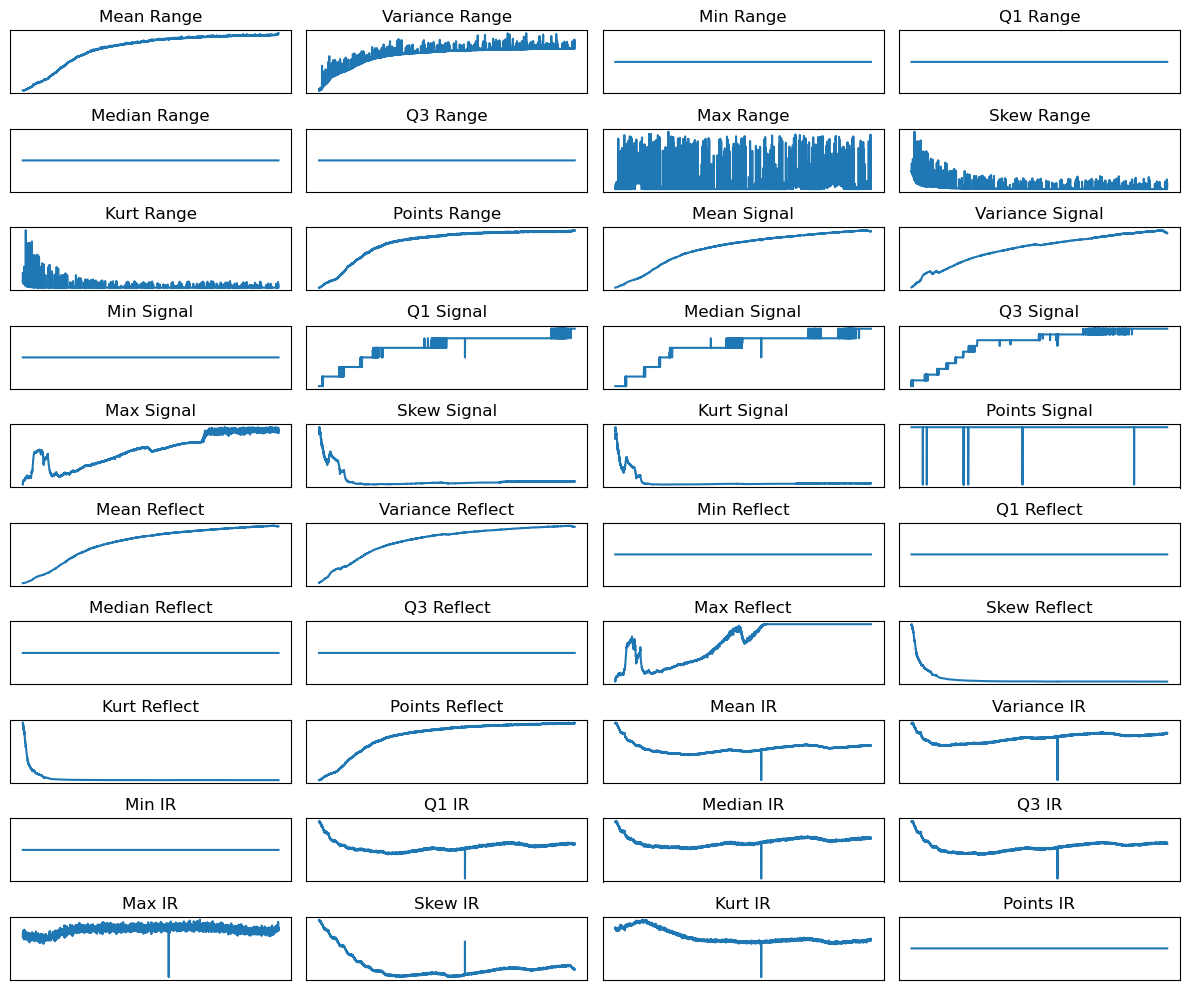

In [117]:
plot_uva(df0, features)

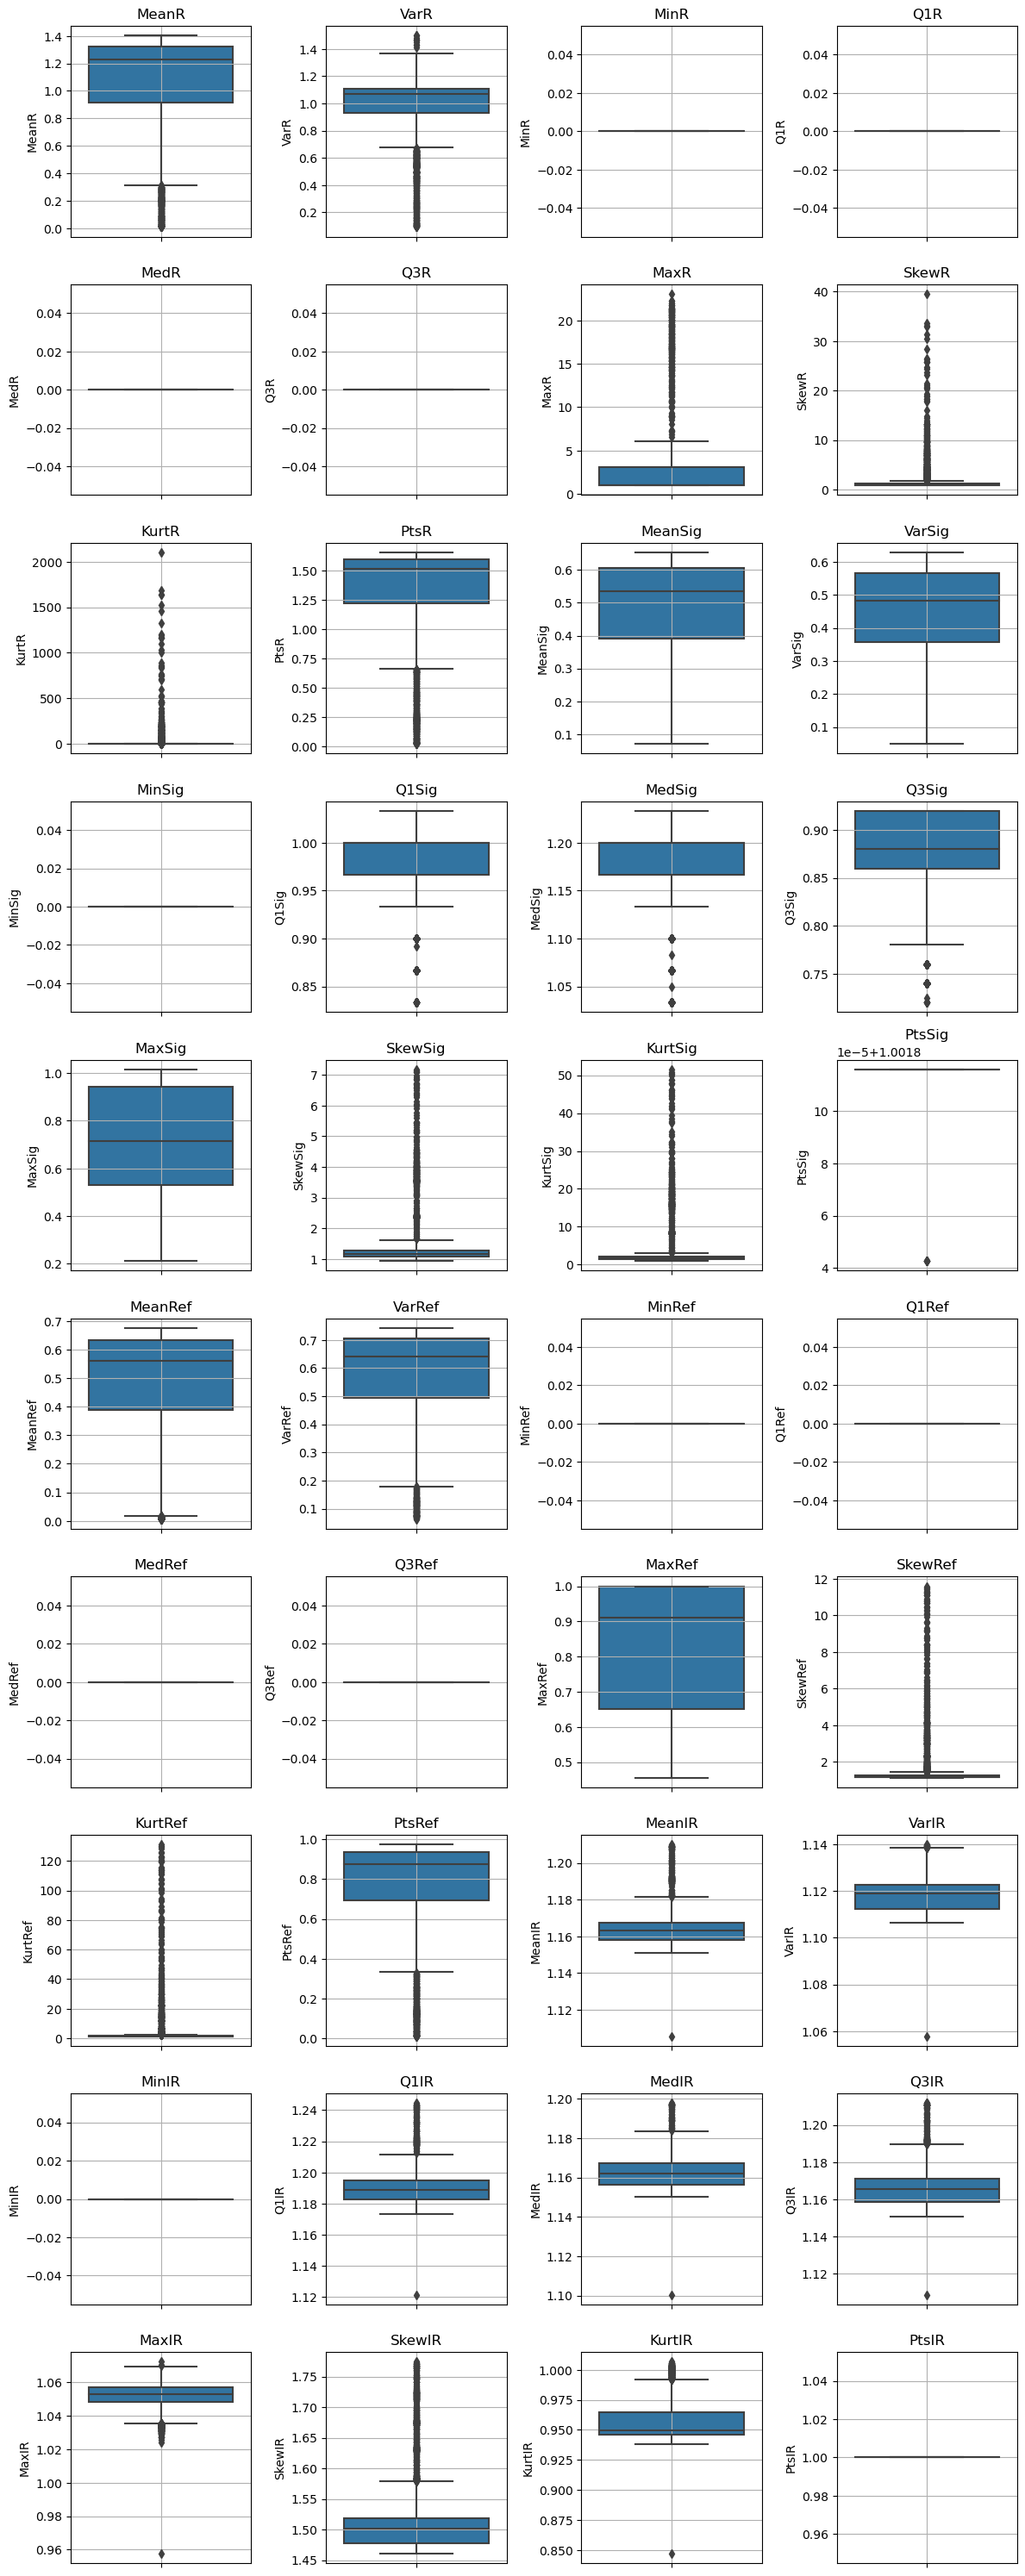

In [57]:
plot_uva(df0, features, plot_type='box')

## BVA
- Distribution analysis of each features against the target
- Correlation Analysis

In [56]:
#Target vs Features
def plot_bva(df, features, target, v_dim = 4, plot_type='scatter'):
    h_dim = math.ceil(len(features) / v_dim)
    fig, axes = plt.subplots(nrows=h_dim, ncols=v_dim, figsize=(12, 2 * h_dim))
    for i, ax in enumerate(axes.flat):
        if plot_type == 'scatter' :
            sns.scatterplot(data=df, y=target, x=features[i], ax=ax)
        else:
            pass
        ax.set_title(feature_names[i])
        ax.set(xlabel=None)
        ax.set_xticks([])
        ax.set_yticks([])        
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [57]:
insig_features = ['MinR','Q1R','MedR','Q3R','MinSig', 'PtsSig', 'MinRef','Q1Ref','MedRef','Q3Ref', 'MinIR', 'PtsIR']
sig_features = [feature for feature in features if feature not in insig_features]

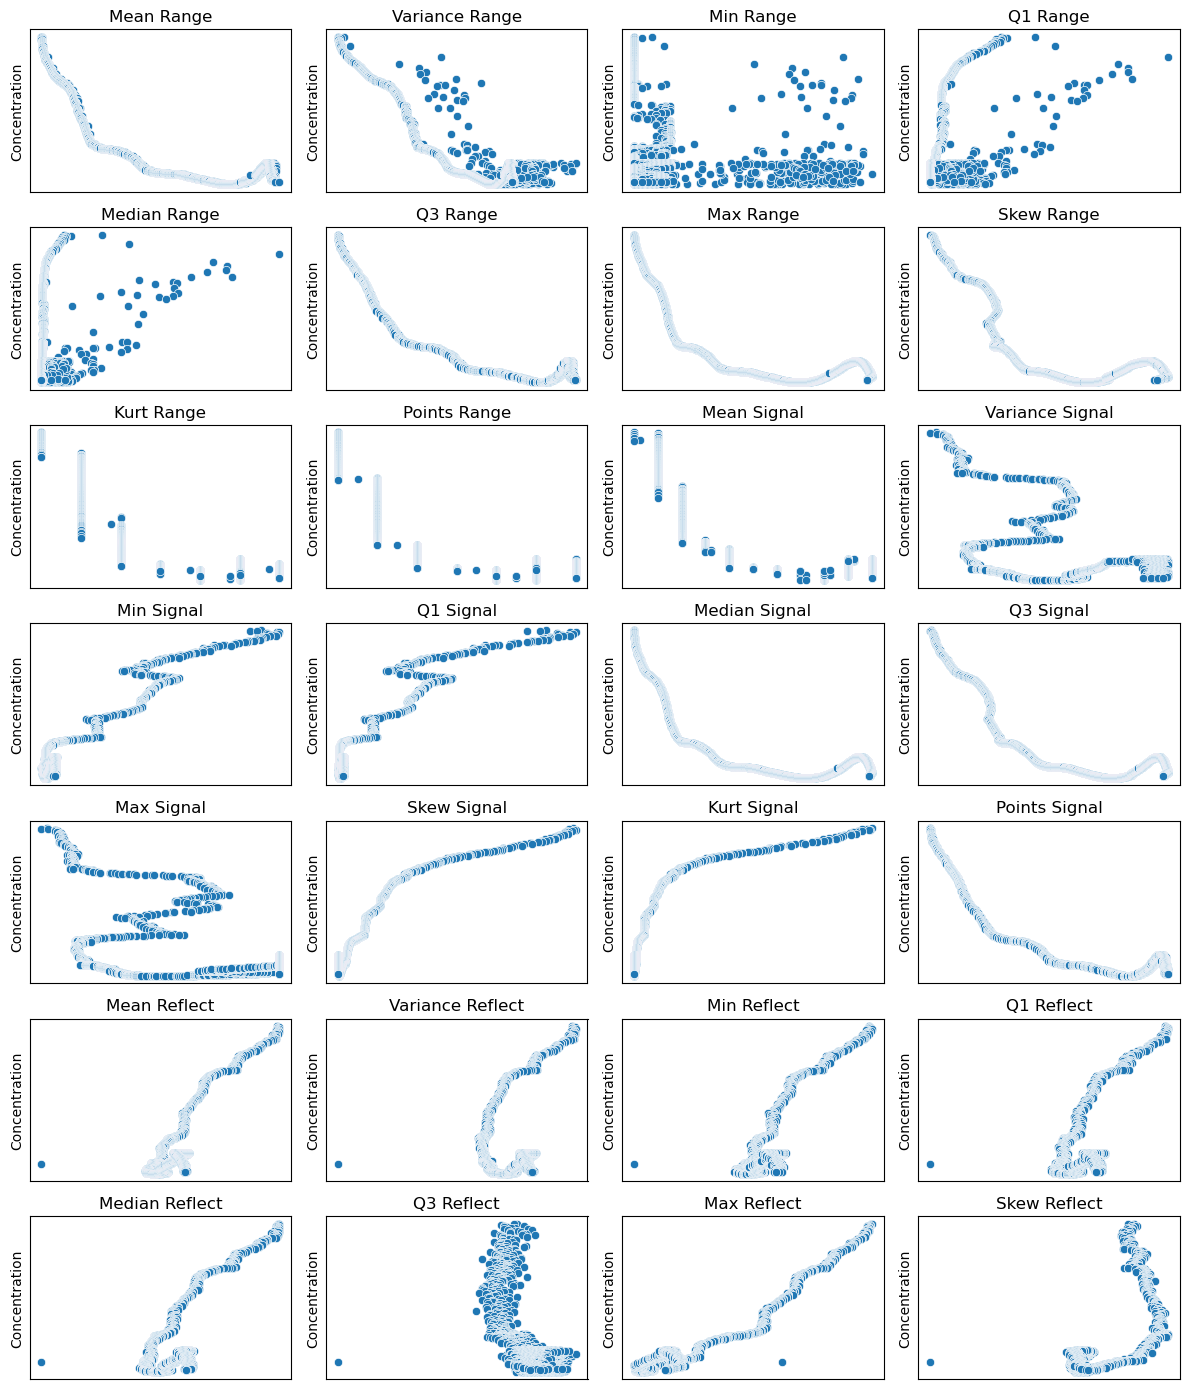

In [60]:
plot_bva(df0.drop(insig_features, axis=1), sig_features, target)

## Correlation with Features

In [46]:
def plot_corr(df, features, target=None, plot_type='Target'):
    plt.figure(figsize=(12,1))
    if plot_type == 'Target':
        corr_res = df[features + [target]].corr().dropna(how='all',axis=1).iloc[-1][:-1]
        corr_res = corr_res.sort_values()
    else:
        corr_df = df[features].corr().dropna(how='all').dropna(how='all',axis=1)
        corr_bin= corr_df.applymap(lambda x: 1 if abs(x) > 0.5 else 0)
        corr_res = corr_bin.sum(axis=1).sort_values()
    ax = sns.heatmap(corr_res.to_frame().T, annot=True, cmap="viridis", linewidths=0.5) #, xticklabels=series.index, yticklabels=["Series"])
    for text in ax.texts:
        text.set_rotation(90)  # Rotate text to vertical
        text.set_fontsize(8)   # Adjust font size if neede
    return corr_res

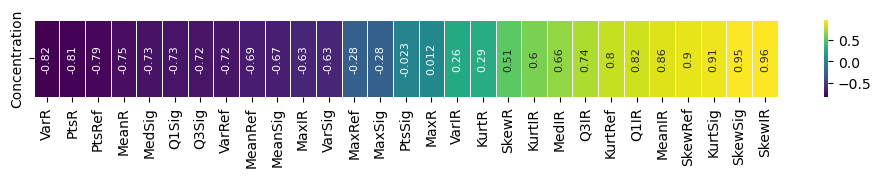

In [47]:
corr_res = plot_corr(df0, features, target)

## Features interdependancy

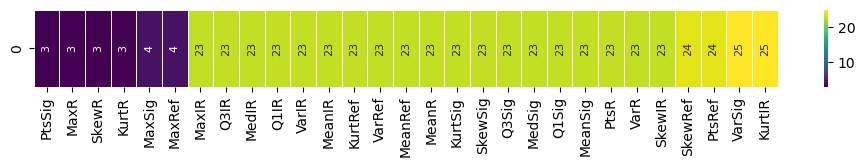

In [162]:
plot_corr(df3, features, plot_type='Features')

# EDA - Experiment 2 Data

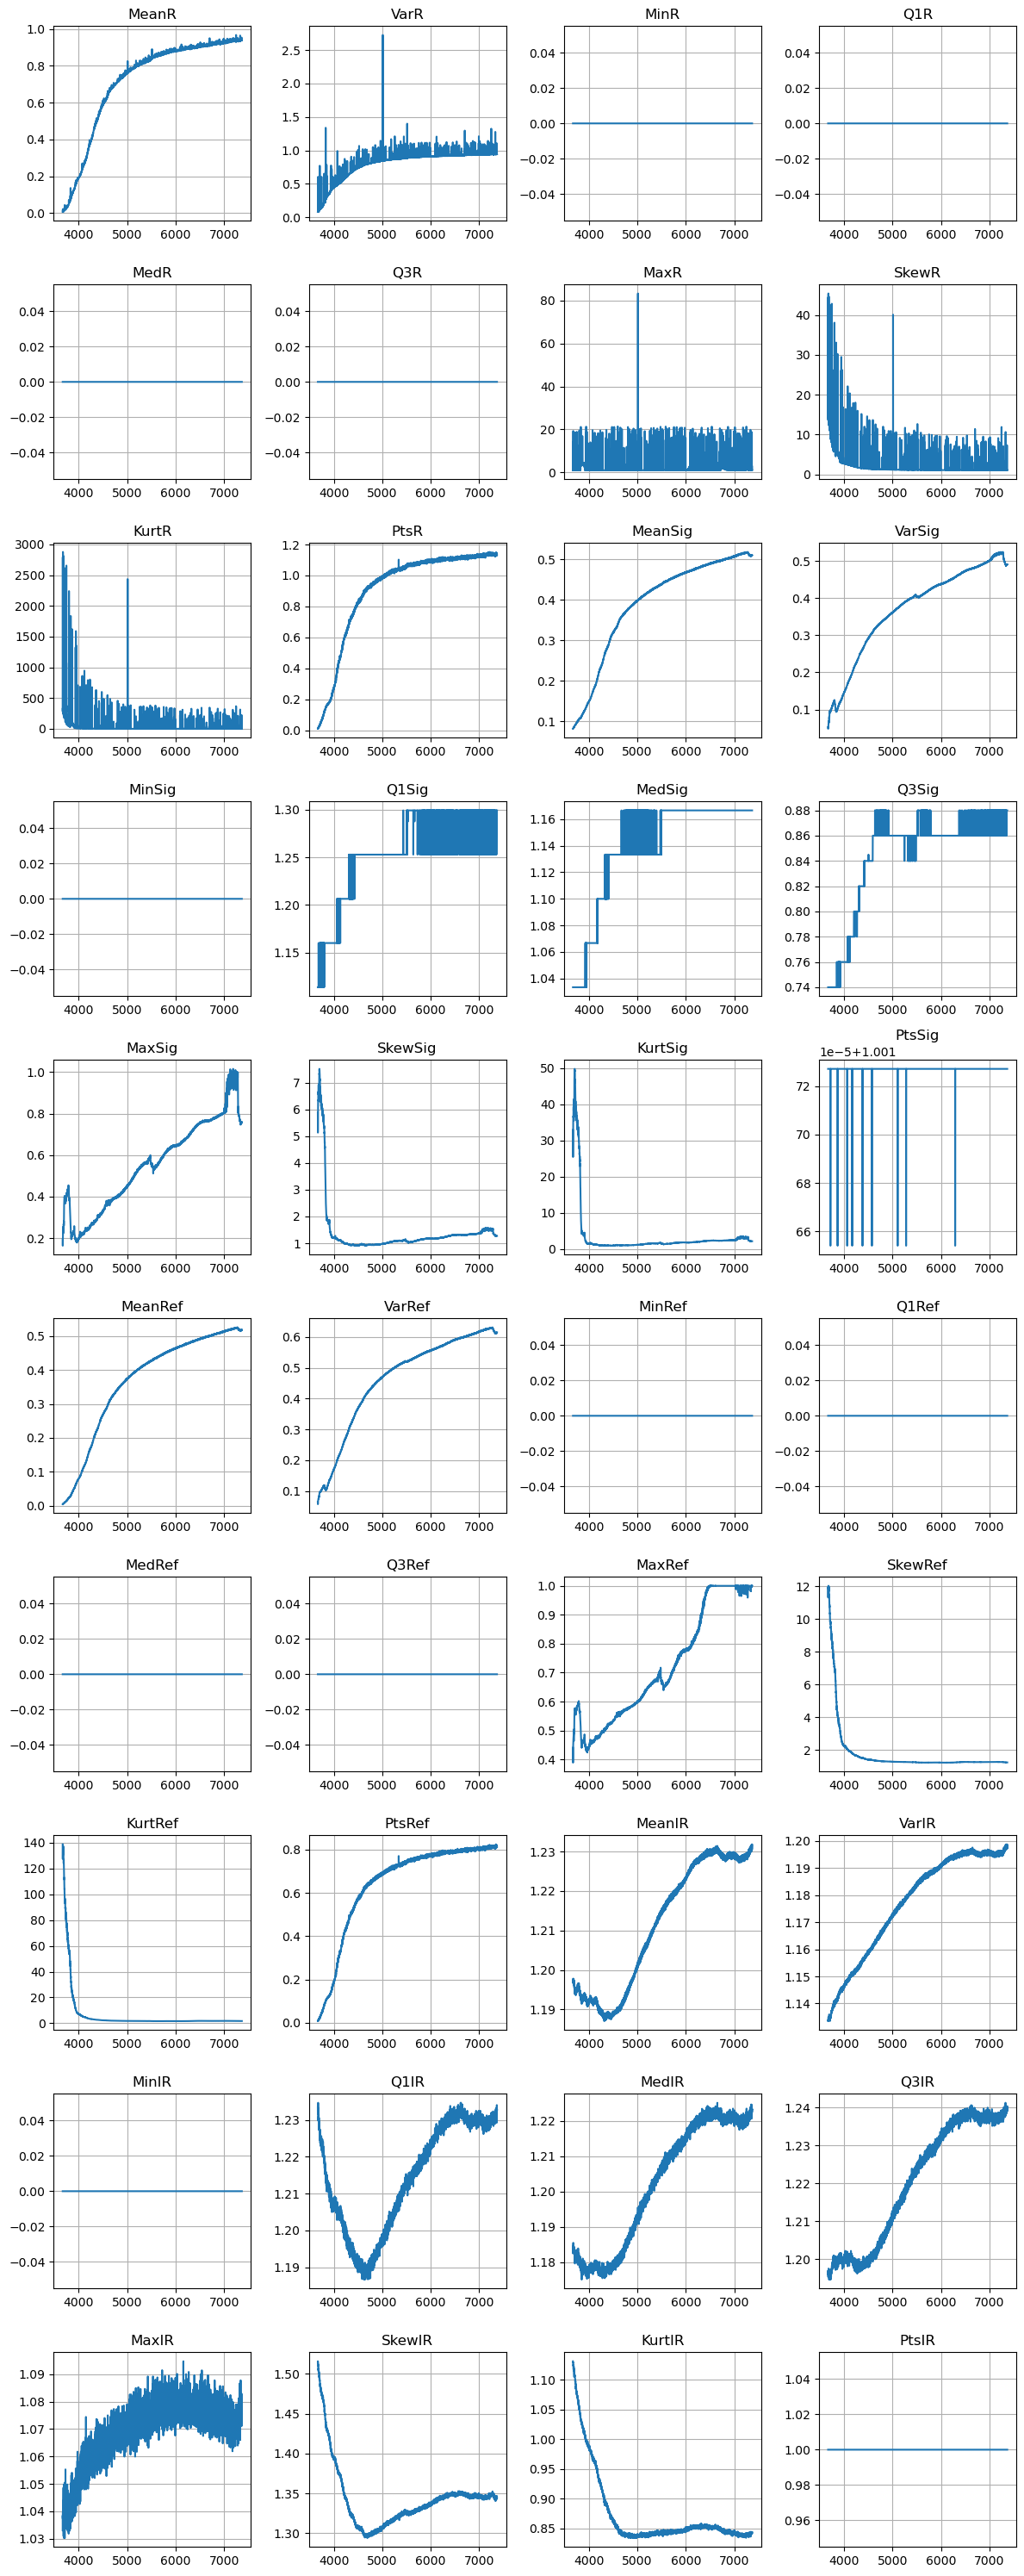

In [91]:
plot_uva(df1, features)

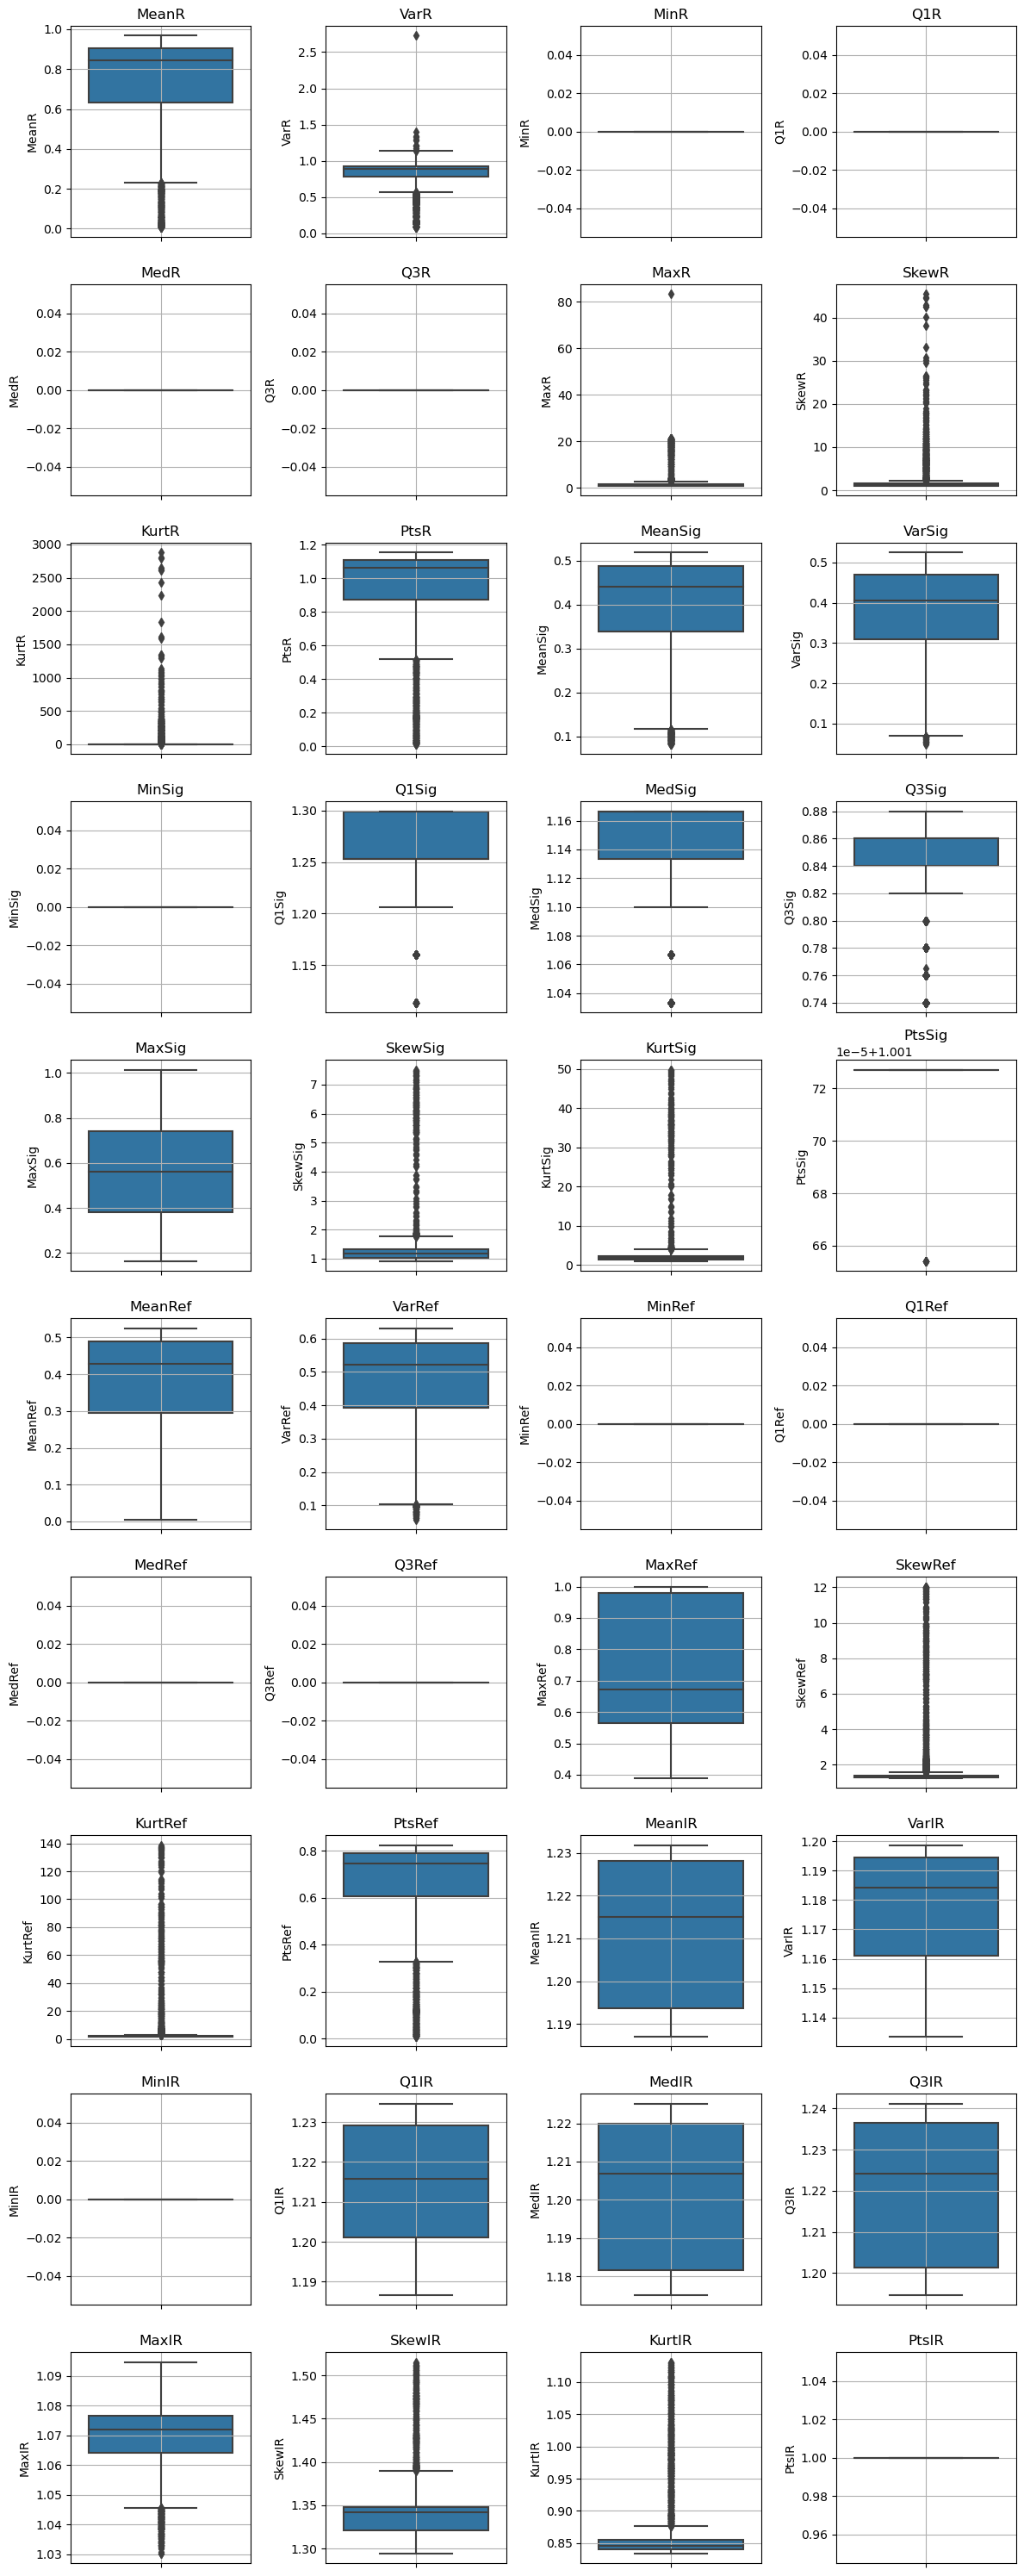

In [92]:
plot_uva(df1, features, plot_type='box')

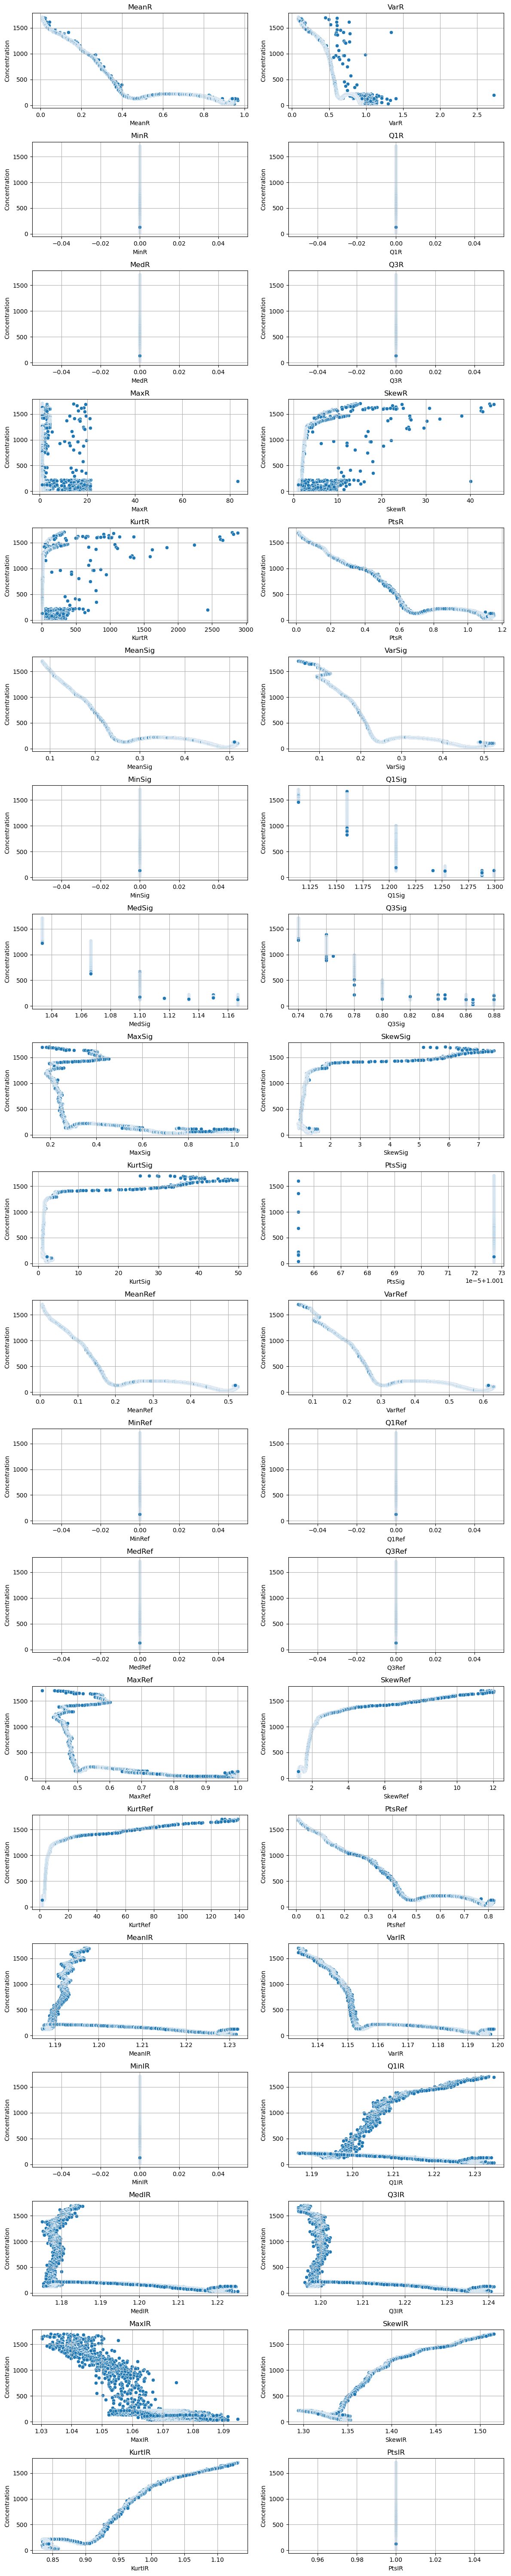

In [93]:
plot_bva(df1, features, target)

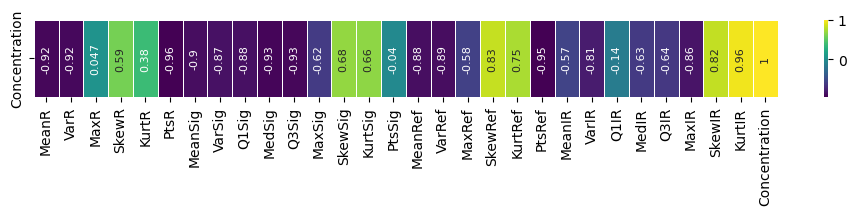

In [177]:
corr_res = plot_corr(df1, features, target)

## Features interdependancy

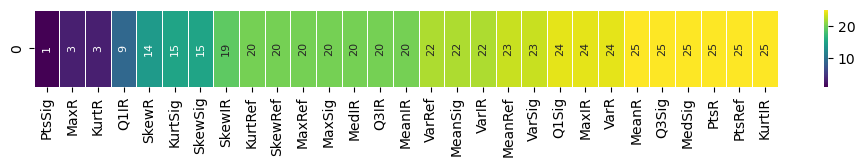

In [172]:
plot_corr(df1, features, plot_type='Features')

# EDA - Experiment 3 Data

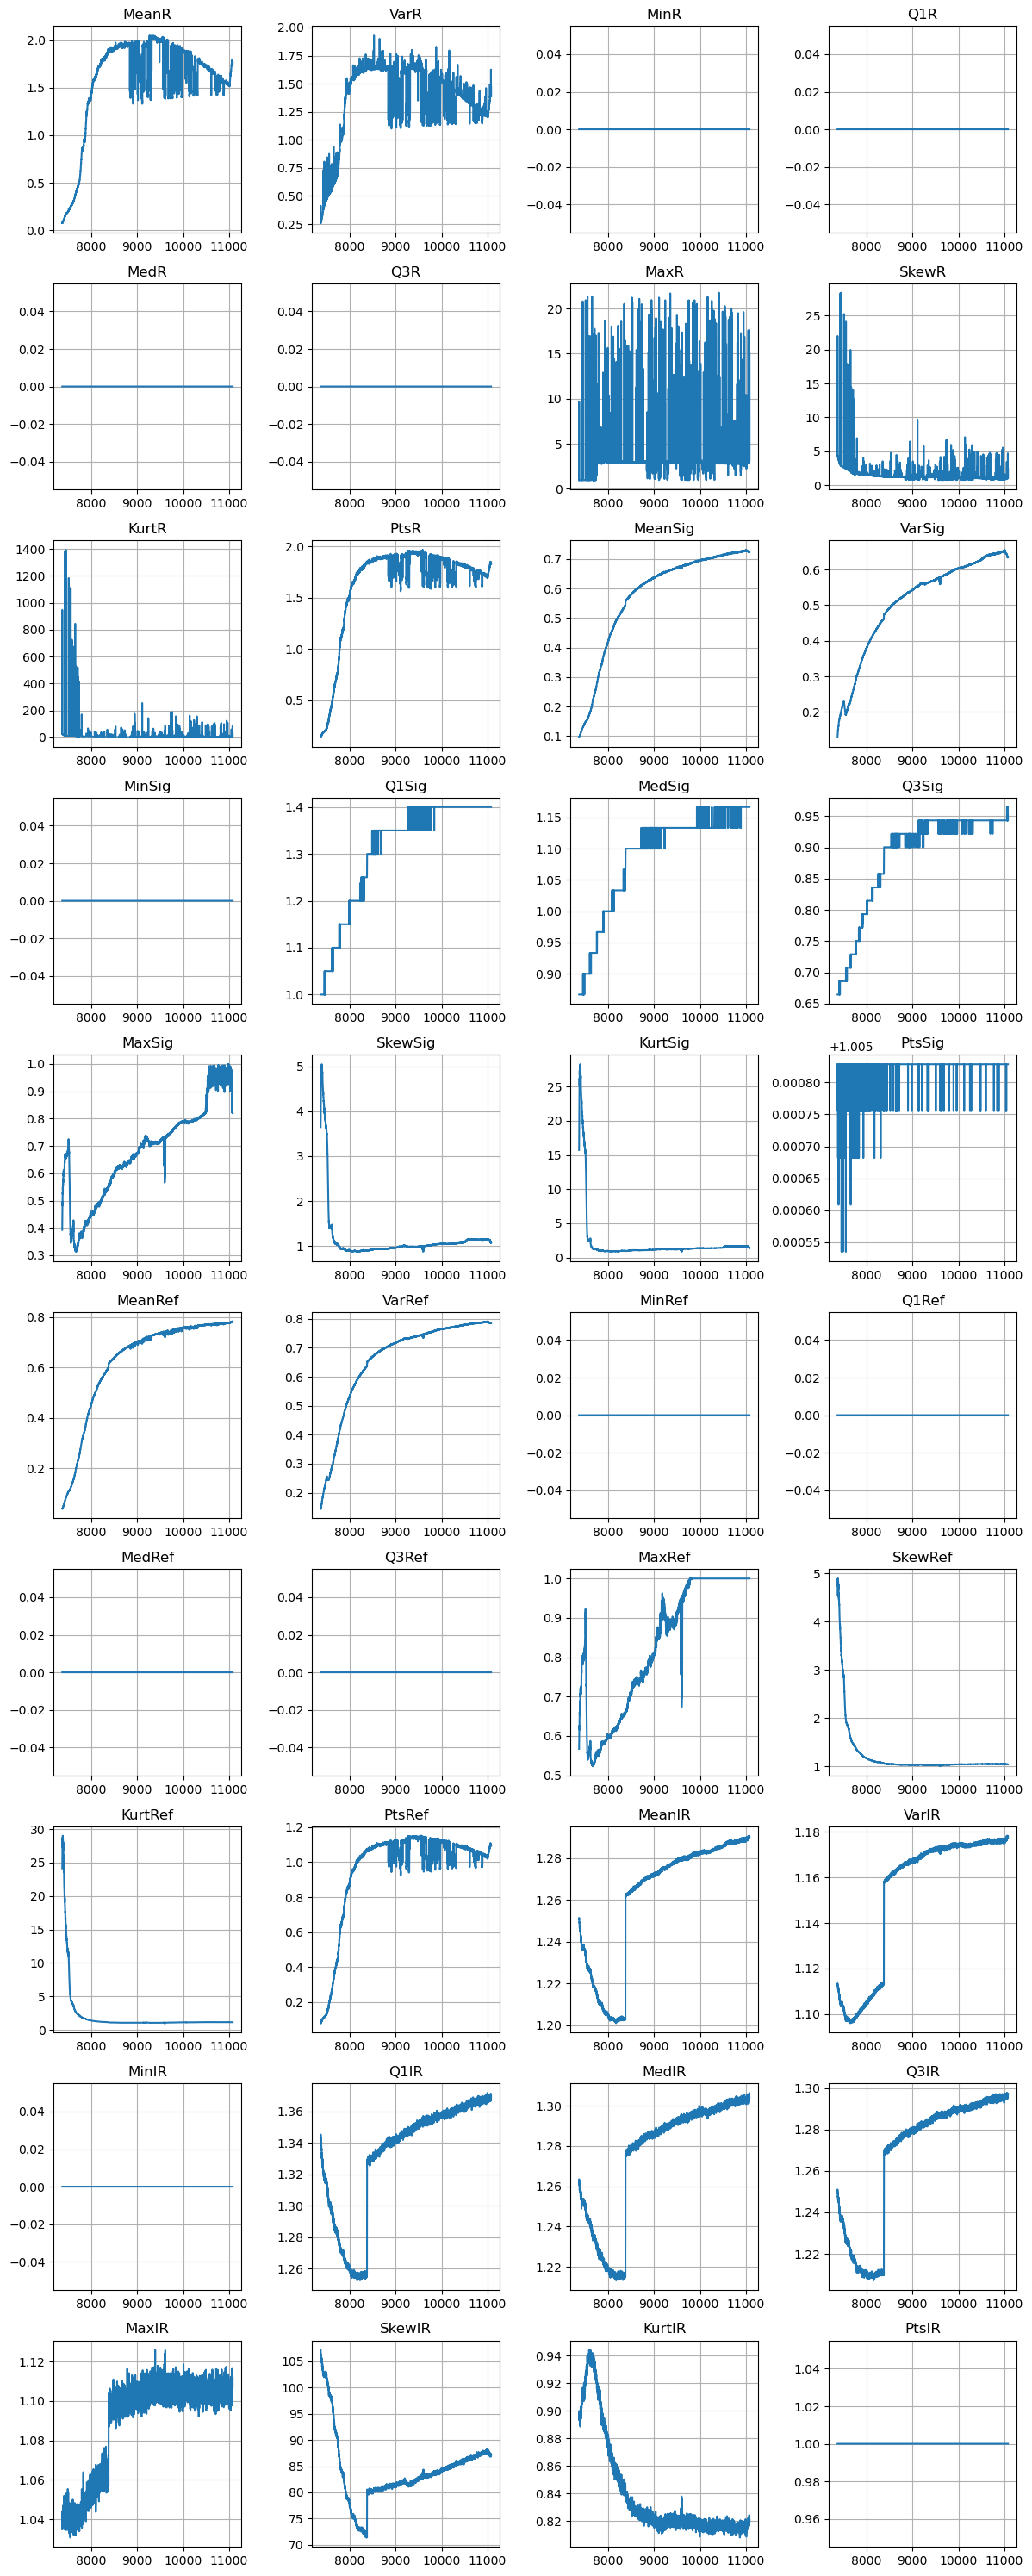

In [95]:
plot_uva(df2, features)

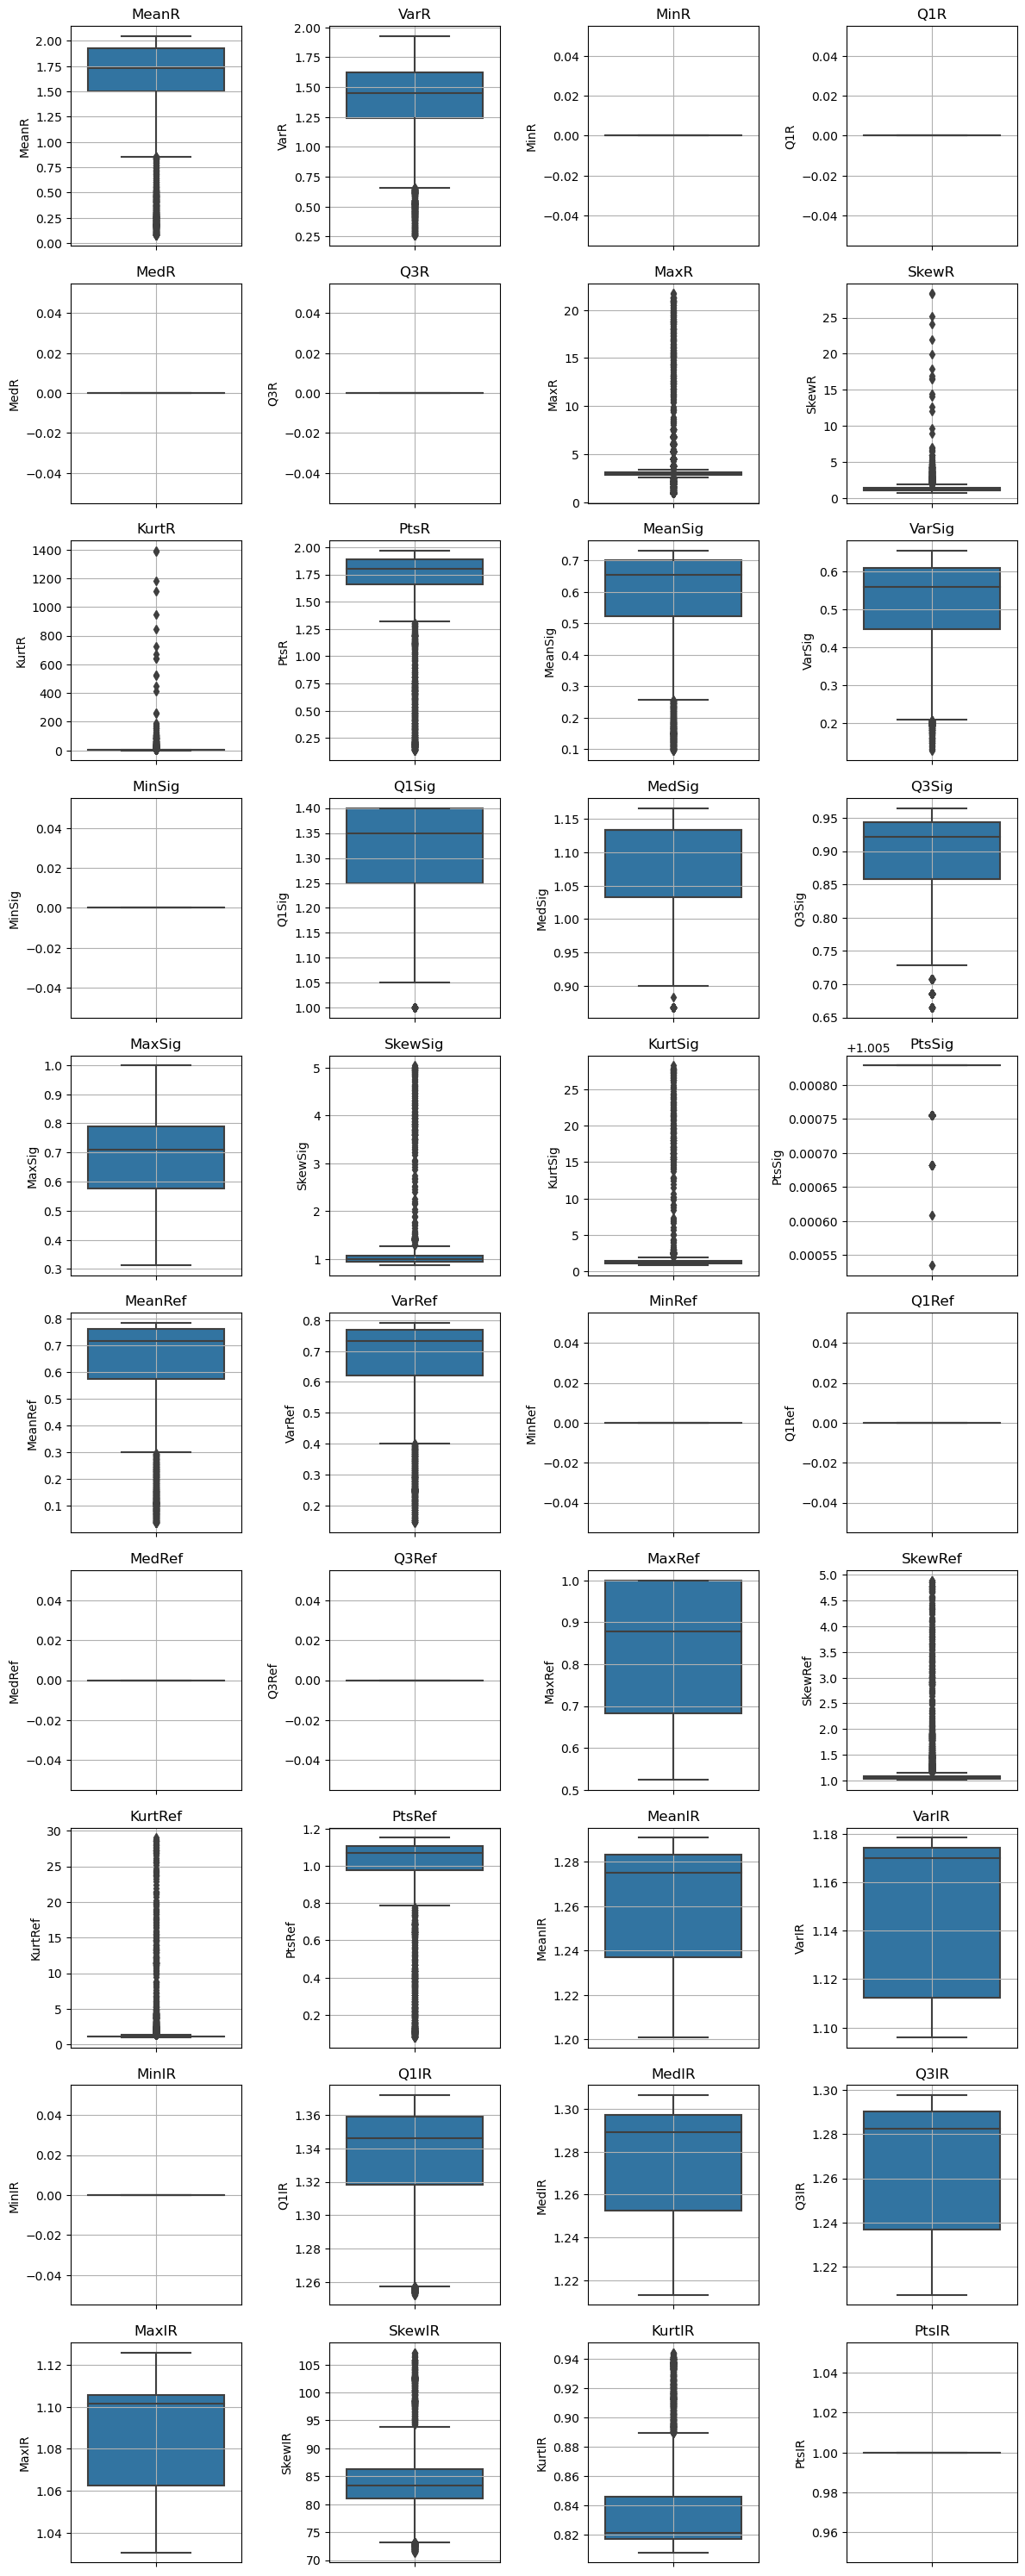

In [96]:
plot_uva(df2, features, plot_type='box')

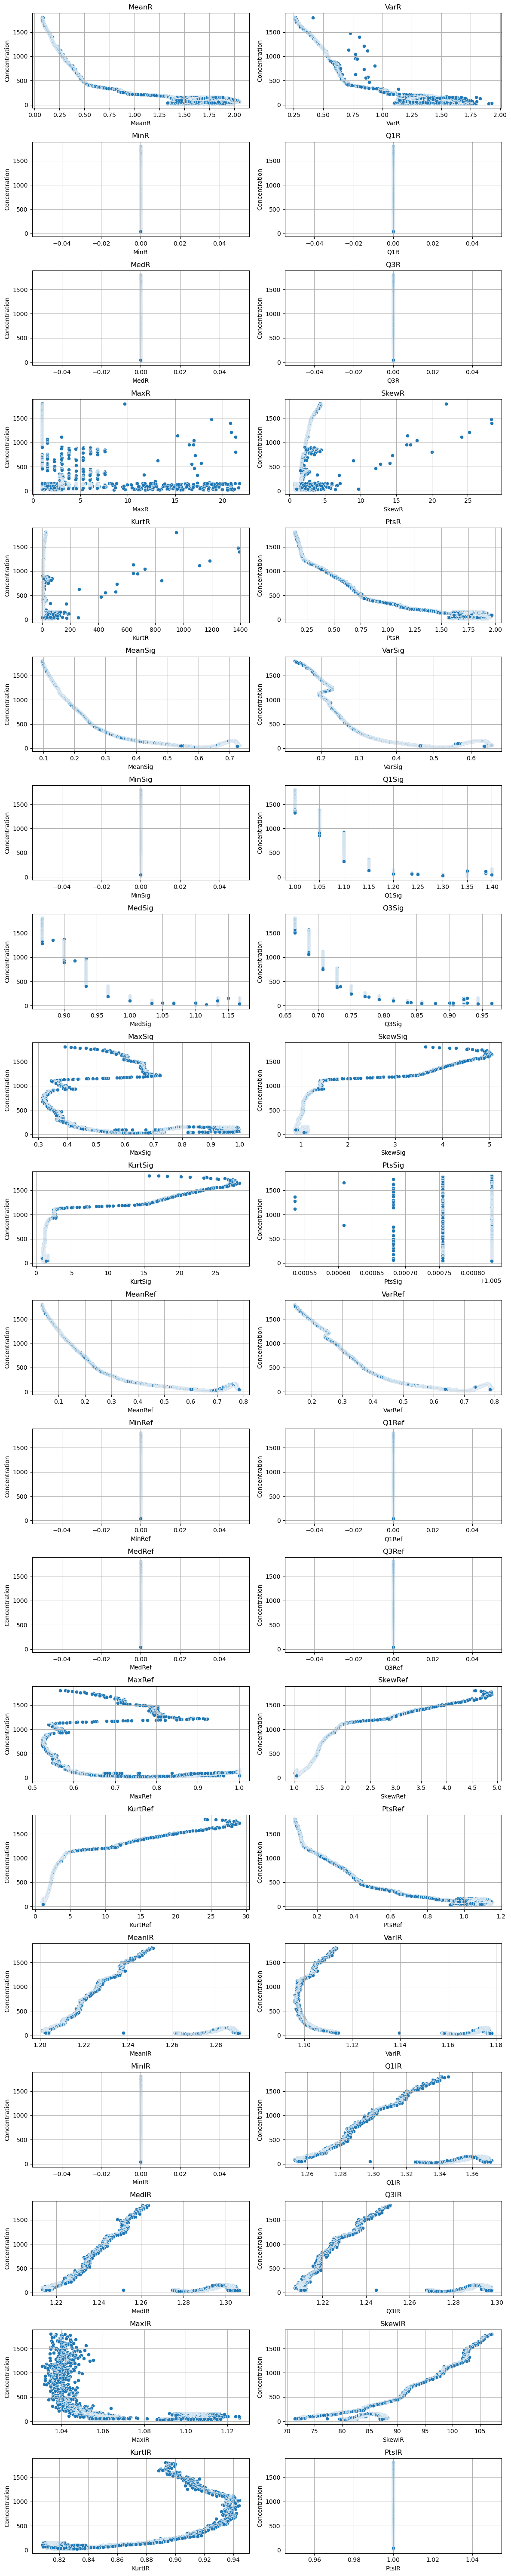

In [97]:
plot_bva(df2, features, target)

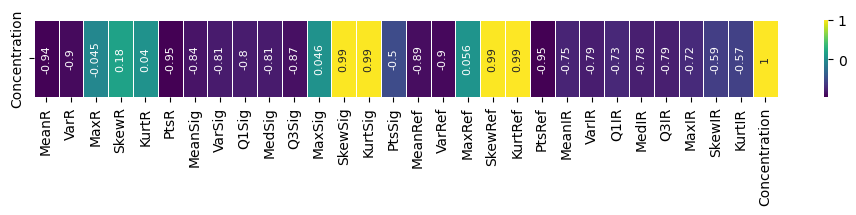

In [176]:
corr_res = plot_corr(df3, features, target)

## Features interdependancy

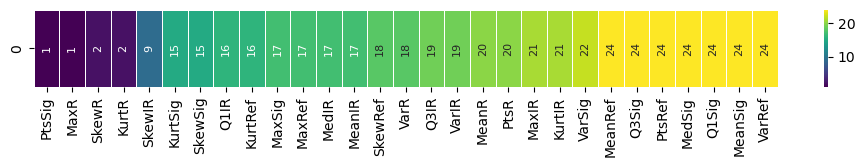

In [175]:
plot_corr(df2, features, plot_type='Features')

# EDA - Experiment 4 Data

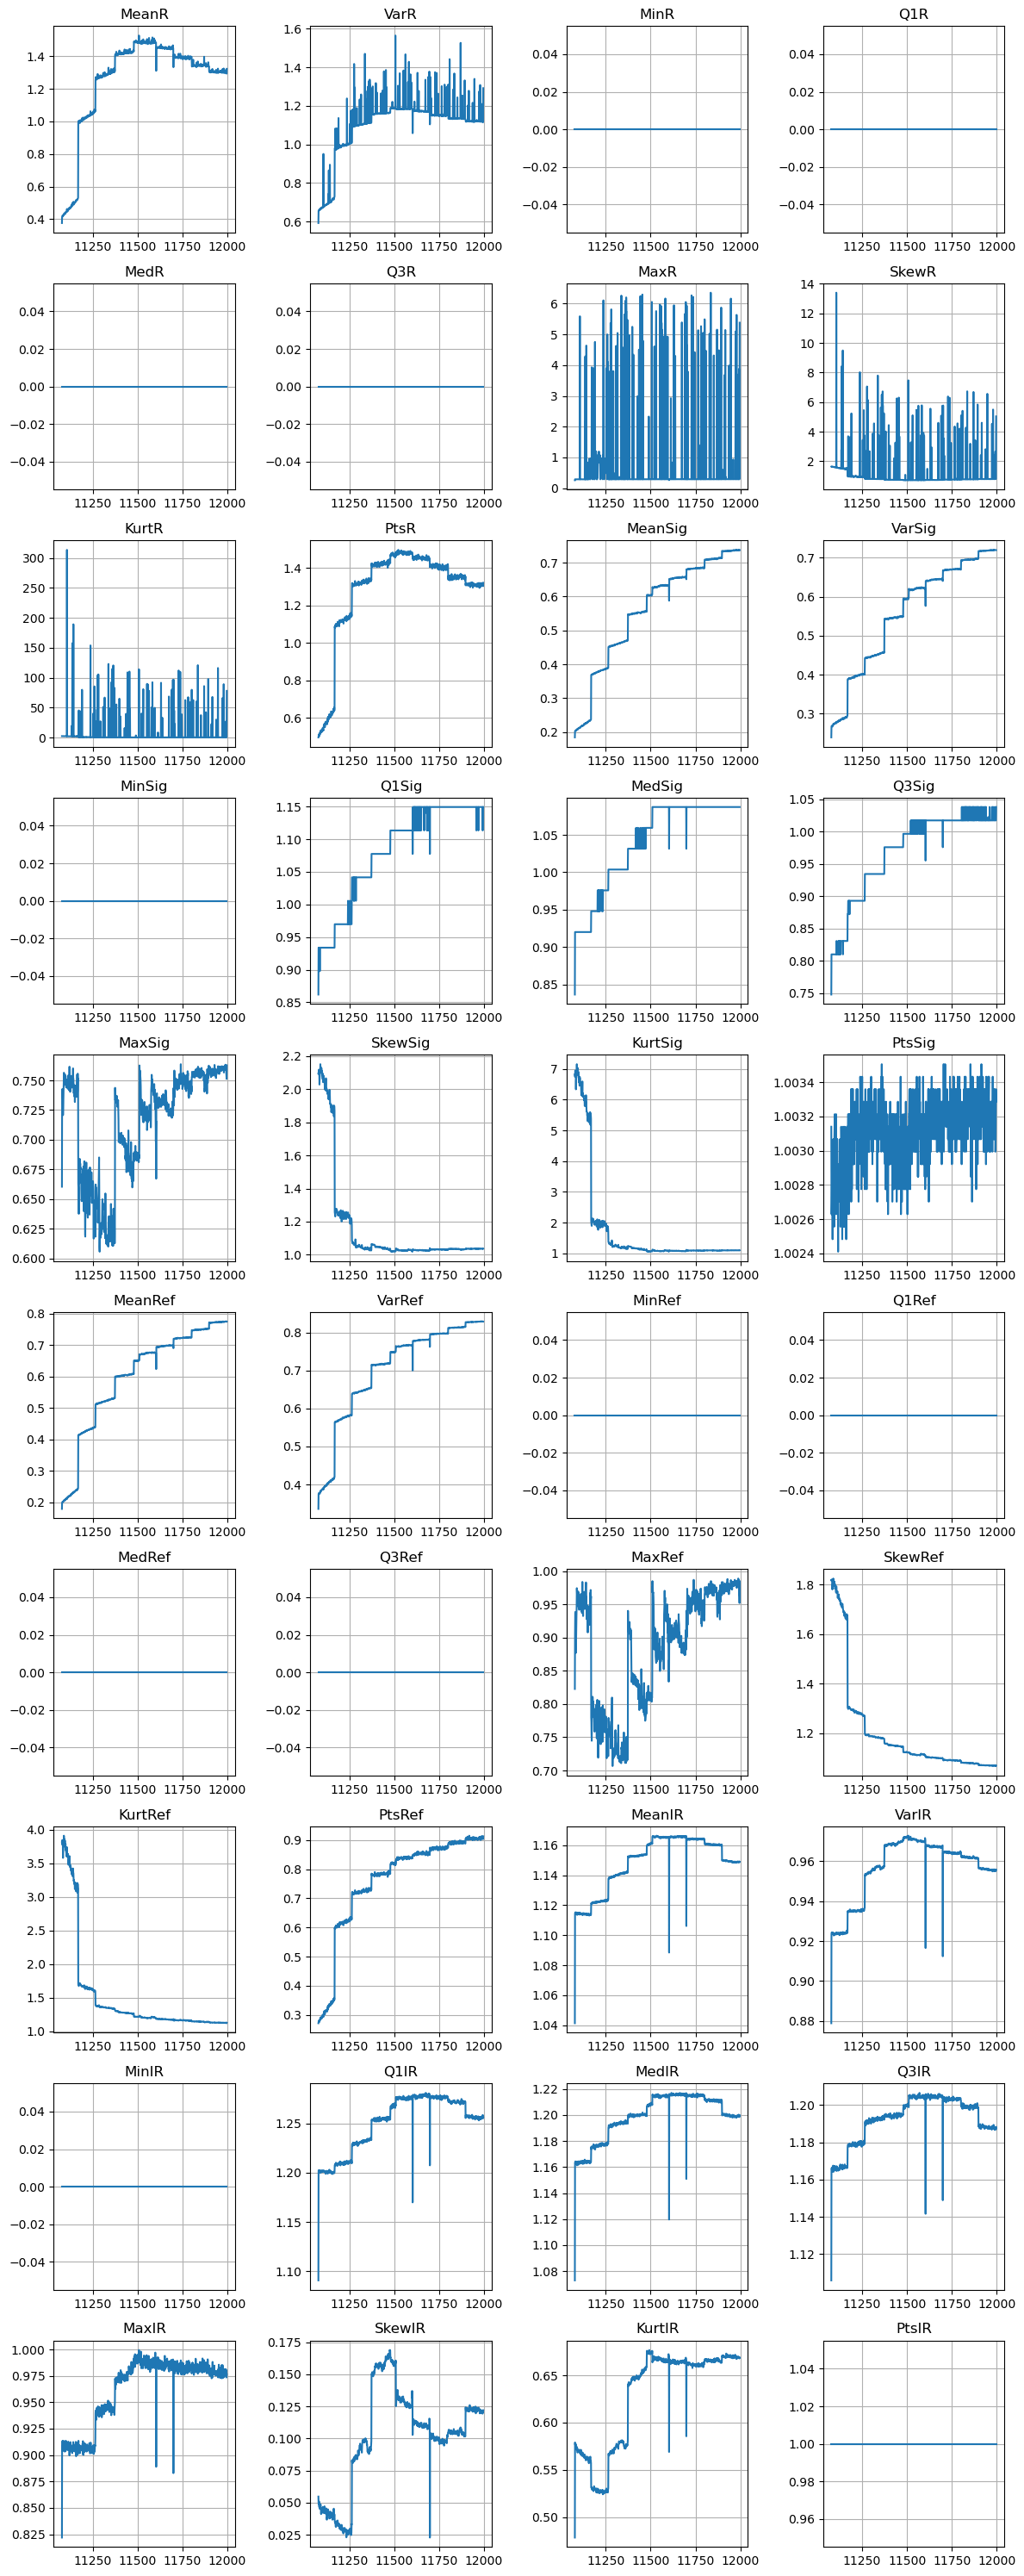

In [99]:
plot_uva(df3, features)

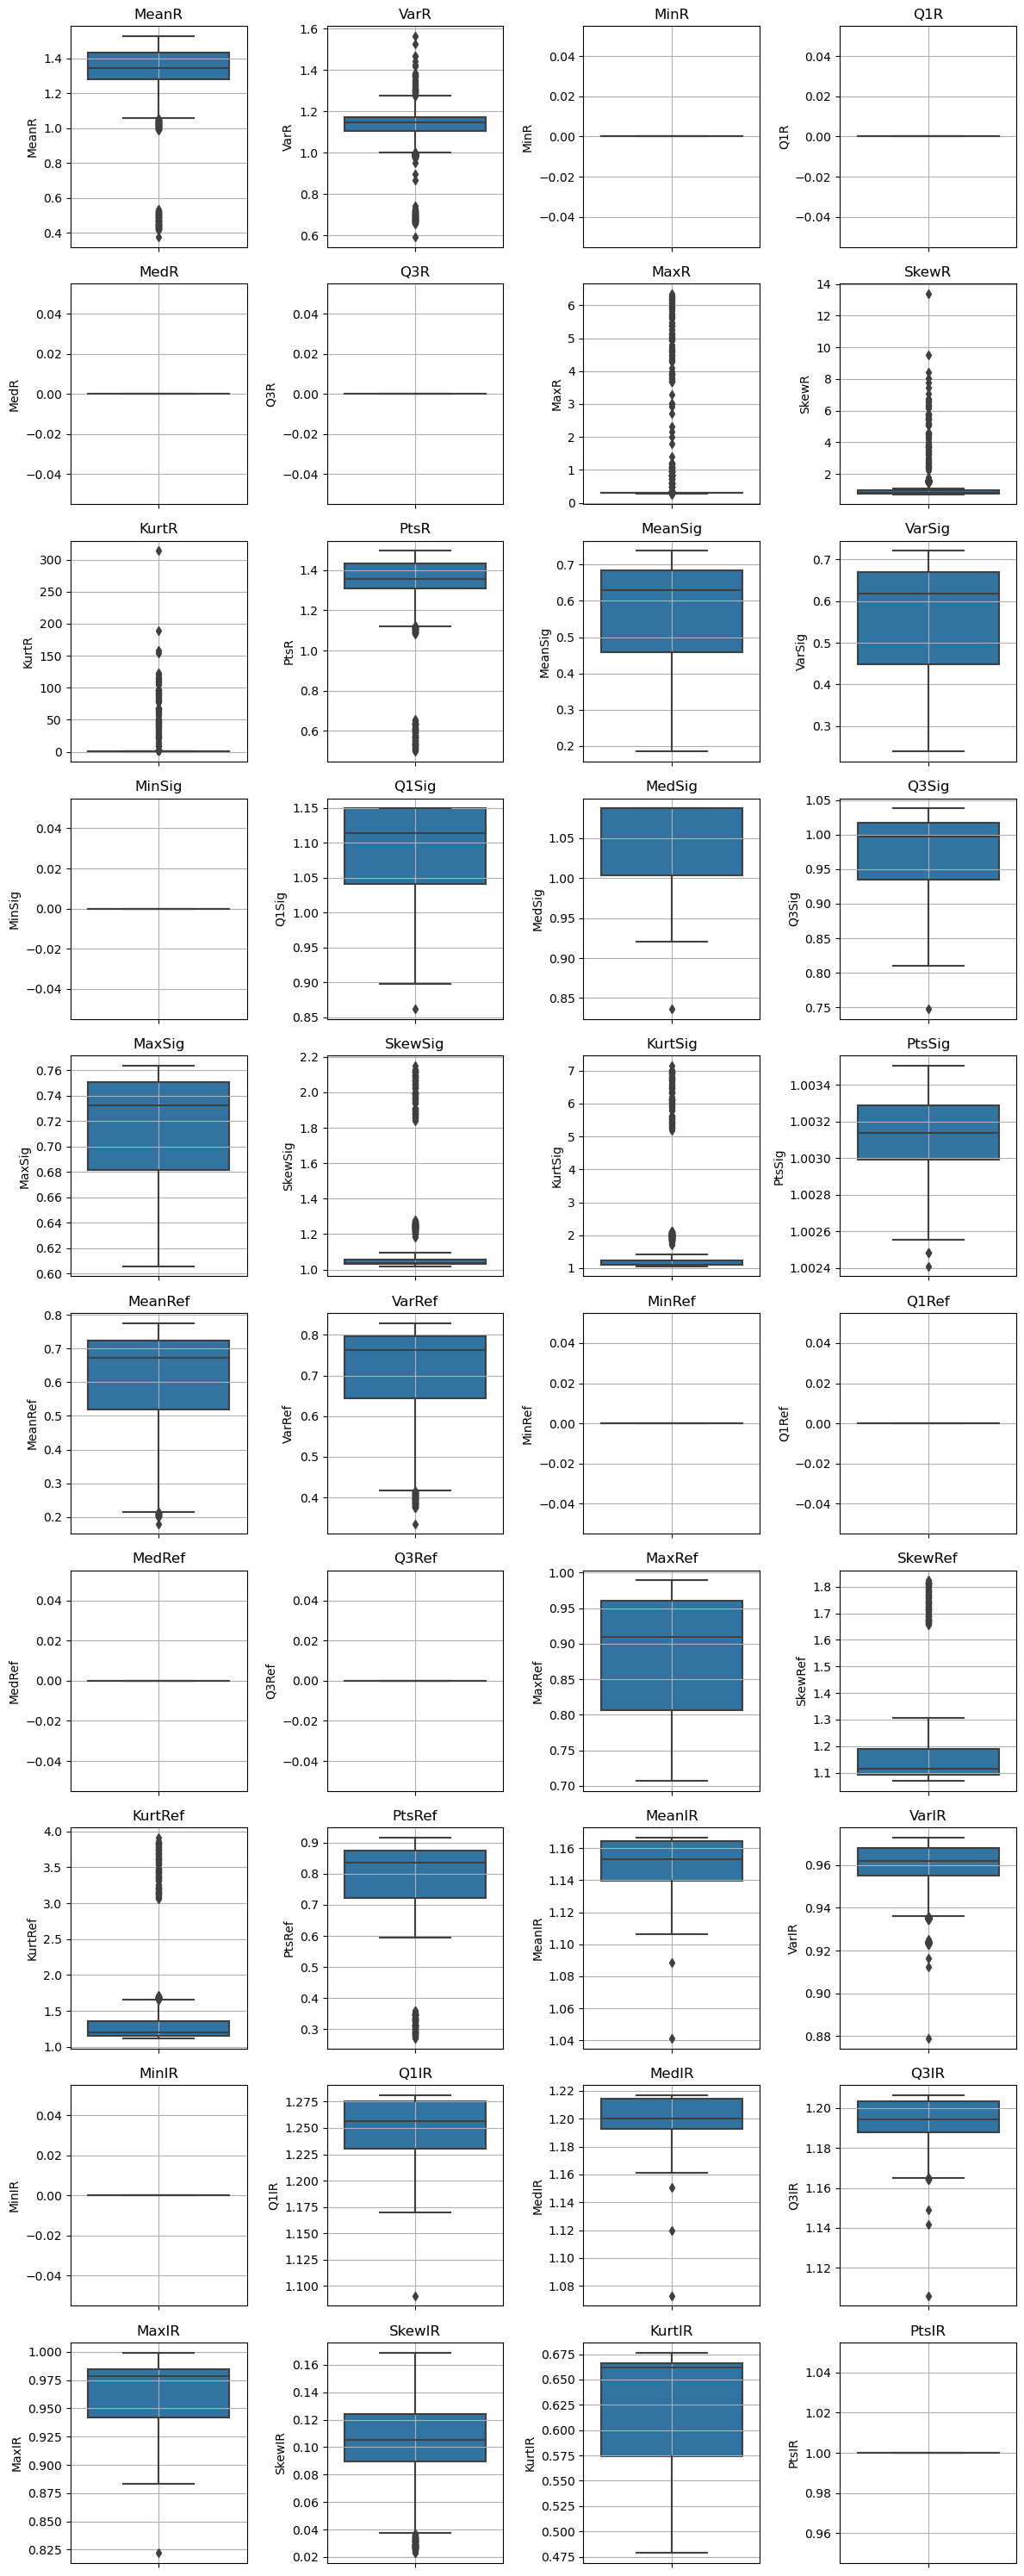

In [100]:
plot_uva(df3, features, plot_type='box')

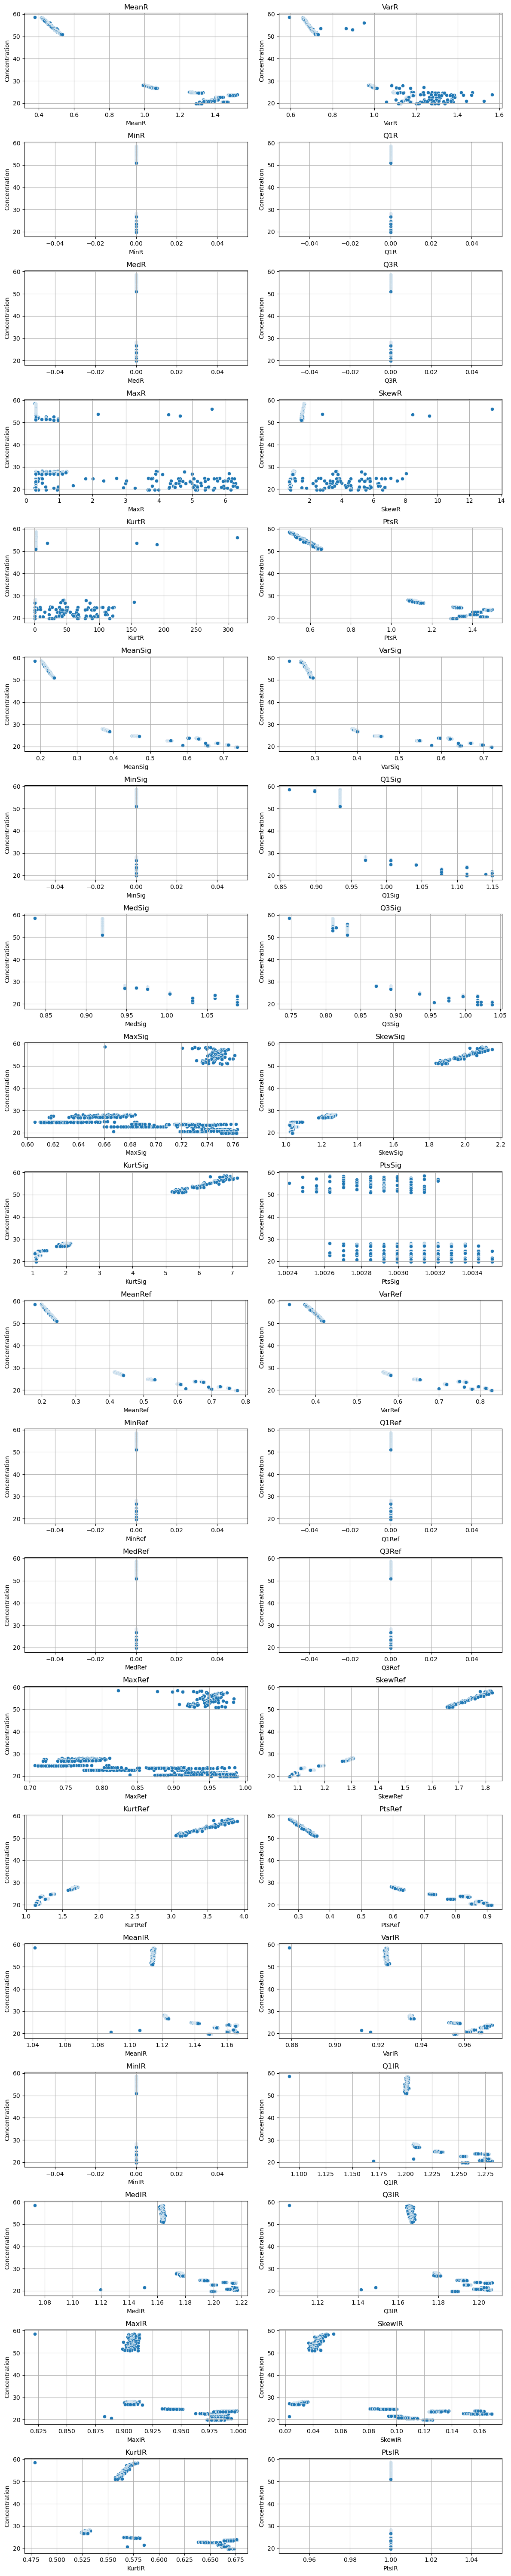

In [101]:
plot_bva(df3, features, target)

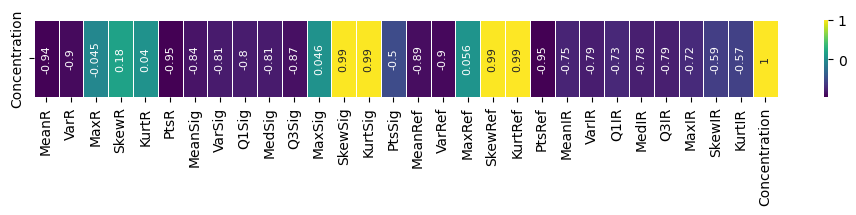

In [174]:
corr_res = plot_corr(df3, features, target)

## Features interdependancy

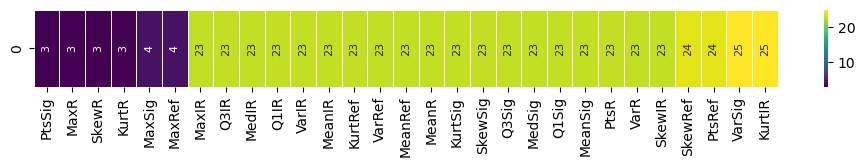

In [173]:
plot_corr(df3, features, plot_type='Features')

# Combined Results of All Experiments

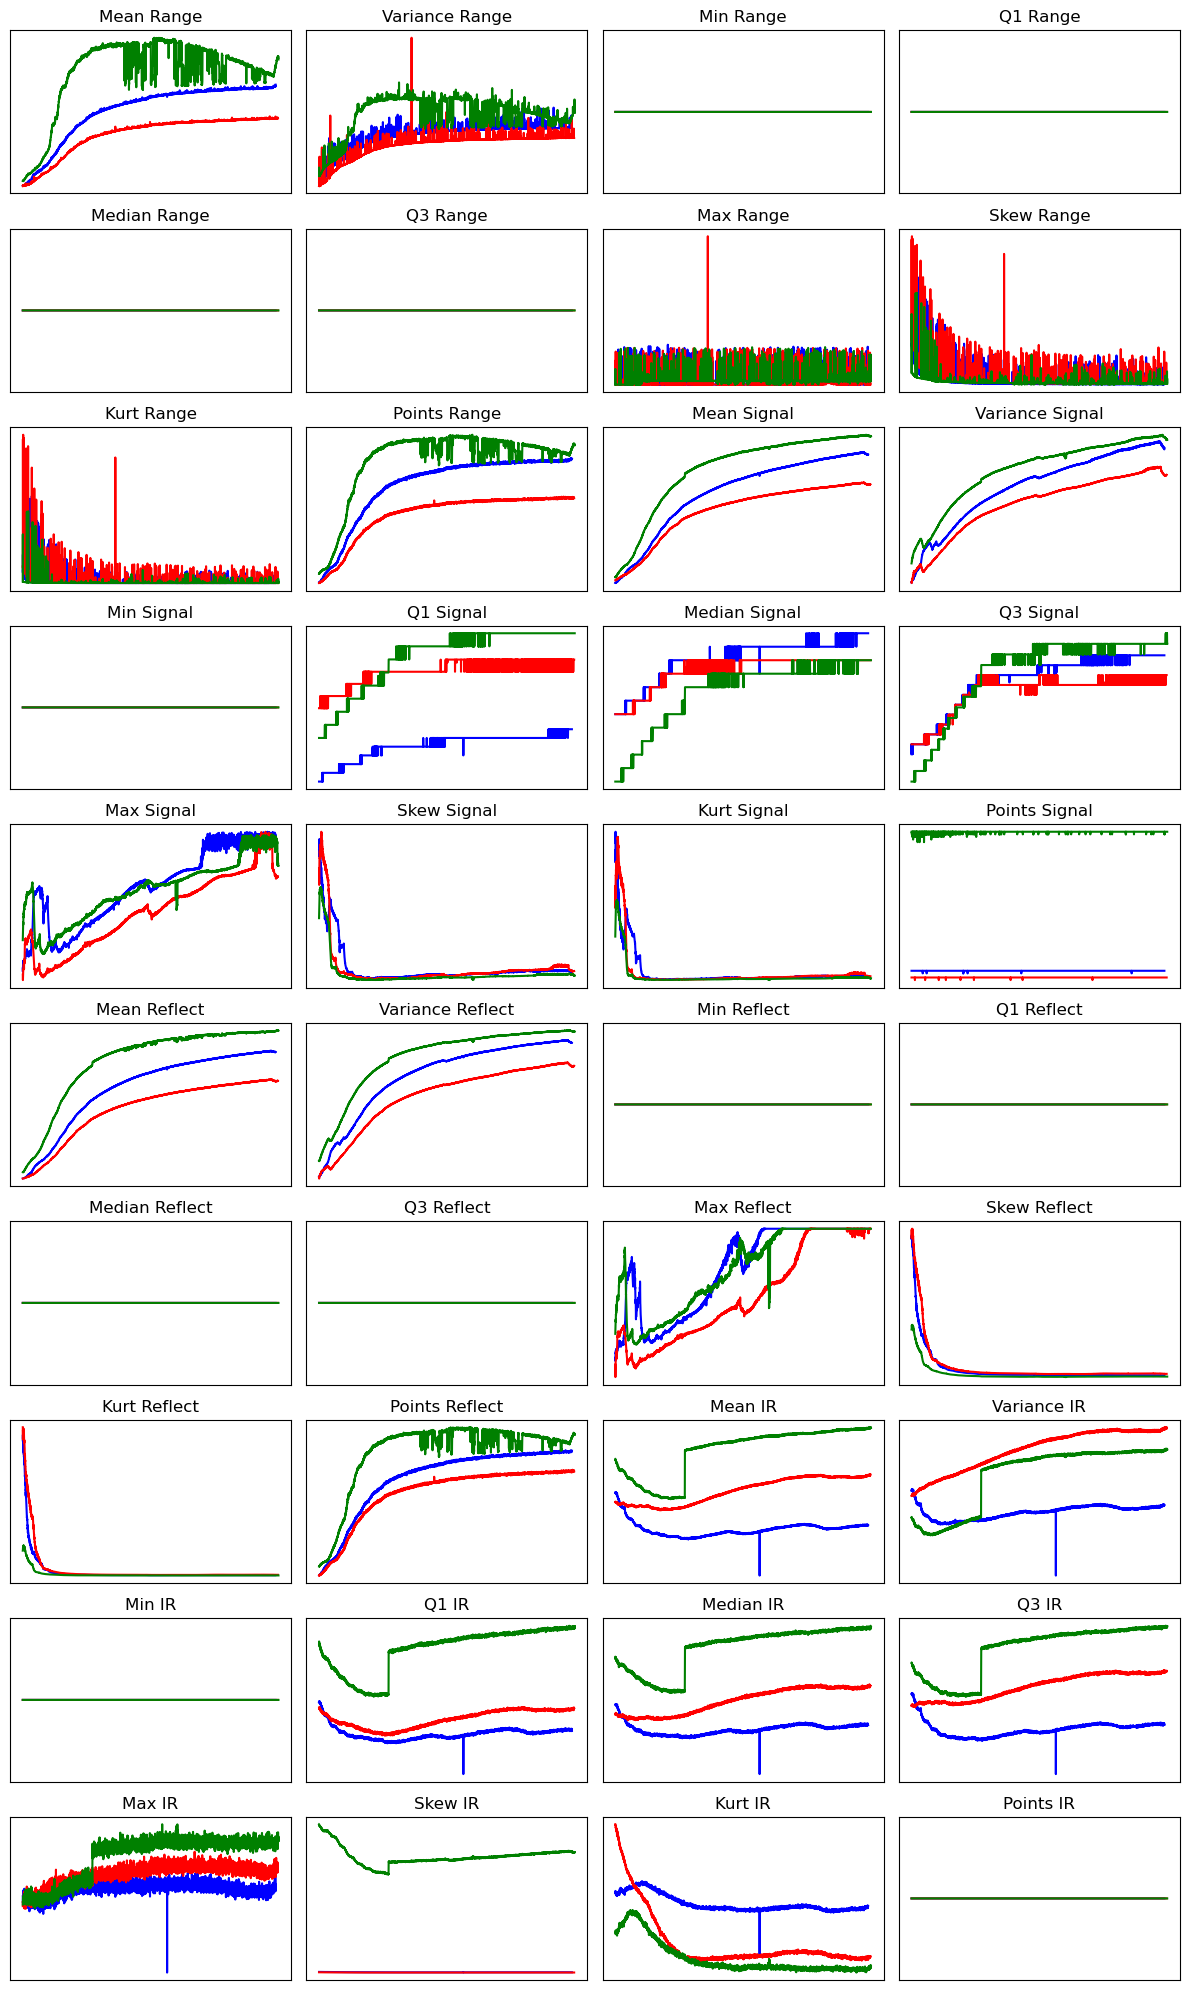

In [115]:
v_dim=4
plot_type = 'line'
h_dim = math.ceil(len(features) / v_dim)
fig, axes = plt.subplots(nrows=h_dim, ncols=v_dim, figsize=(12, 2 * h_dim))
for i, ax in enumerate(axes.flat):
    if plot_type == 'line' :
        ax.plot(np.arange(len(df0)), df0[features[i]], color='b')
        ax.plot(np.arange(len(df1)), df1[features[i]], color='r')
        ax.plot(np.arange(len(df2)), df2[features[i]], color='g')
    else:
        sns.boxplot(data=df, y=features[i], ax=ax)
    ax.set_title(feature_names[i])
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.grid(True)

plt.tight_layout()
plt.show()

# Principal Component Analysis

In [72]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [99]:
scaler = RobustScaler()
df_all = df0.iloc[:, 4:-1]

In [100]:
df_all_scaled = scaler.fit_transform(df_all)

In [101]:
pca = PCA(n_components=df_all.shape[1])

In [102]:
pca.fit(df_all_scaled)

PCA(n_components=40)

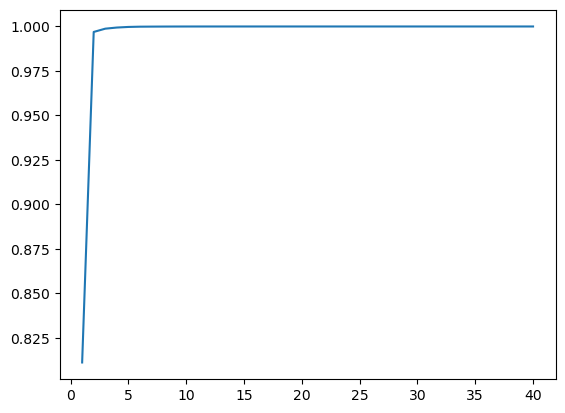

In [103]:
plt.plot(np.arange(1,df_all.shape[1]+1), pca.explained_variance_ratio_.cumsum())

In [105]:
X = pca.transform(df_all_scaled)

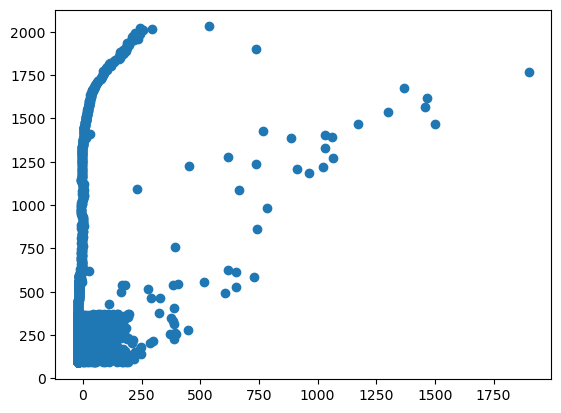

In [108]:
plt.scatter(X[:,0], df0['Concentration'])

# Prepared By Muthukumar G